# LeafGen: Structure-aware Leaf Image Generation for Annotation-free Leaf Instance Segmentation
**Minimal single-plant demonstration** (komatsuna, 1 model, 1 render) of the generation pipeline from:

> *LeafGen: Structure-aware Leaf Image Generation for Annotation-free Leaf Instance Segmentation* — Plant Phenomics (2025), DOI: [10.1016/j.plaphe.2025.100092](https://doi.org/10.1016/j.plaphe.2025.100092)

Author code: [RightzZ/structure_gen](https://github.com/RightzZ/structure_gen) @ commit `e32060d365ff7f1cea95b7985abdbd63c67592eb` (Apache-2.0).

**What this notebook does** — reproduces the author pipeline headless (GUI actions → CLI/code mapping):
1. **Mask generation**: L-system plant modeling + Blender rendering of leaf masks (author's modified Blender build).
2. **Data management**: mask inversion, per-leaf cropping, ground-truth instance masks (author `proc_data.py`).
3. **Texturing**: pretrained pix2pix (komatsuna leaf generator, epoch 200) colors each leaf mask; composite over a background (author `texturing.py` functions).

**Not covered** (out of scope): dataset-scale generation, pix2pix *training*, and the downstream MaskDINO segmentation training/evaluation of the paper.

**Adaptations** (documented where used): device selection (`texturing.py` CLI hardcodes `cuda`, we pass the detected device); on CPU-only runtimes the author `networks.init_net` CUDA assert is bypassed (identical ops otherwise); komatsuna texturing is leaf-only because the authors' komatsuna checkpoint contains only a leaf generator (verified from `ckpt.zip`) and their komatsuna processing creates no branch masks.

**状態**: 実行済みの検証済みノートブックです。生成パイプライン(マスク生成→マスク処理→テクスチャリング)の最小例を再現します。データセット規模の生成・学習・下流セグメンテーションは対象外です。

## Runtime selection
**Recommended runtime: CPU** (Runtime → Change runtime type → CPU). The Blender rendering is CPU-based and the pix2pix inference is a few 256×256 U-Net forward passes; a GPU is not required. The notebook auto-detects a GPU if one is allocated and uses it for inference.

Expected cost (measured on a free CPU runtime, 2026-10-01): ~10–15 min end-to-end, ~1.4 GB downloads (author Blender build 297 MB, pretrained checkpoints 872 MB zip, repository snapshot ~190 MB).

**Run all**: Runtime → Run all. すべてのセルを上から順に実行してください。推奨ランタイムは CPU です。

In [ ]:
# Environment setup: Blender needs a virtual display and X libraries (per author "Mask Generation.md")
import sys, subprocess, time, os, glob, shutil, json
t0 = time.time()
subprocess.run(['apt-get','-qq','update'], check=True)
subprocess.run(['apt-get','-qq','install','-y','xvfb','libxi6','libxrender1'], check=True)
subprocess.run([sys.executable,'-m','pip','-q','install','gdown'], check=True)
import torch, cv2, gdown
print('python', sys.version.split()[0])
print('torch', torch.__version__, '| cuda available:', torch.cuda.is_available())
print('opencv', cv2.__version__, '| gdown', gdown.__version__)
print(f'setup done in {time.time()-t0:.1f}s')

python 3.13.15
torch 2.11.0+cpu | cuda available: False
opencv 4.14.0 | gdown 5.2.2
setup done in 21.9s


## 1. Acquisition of pinned sources
Downloads (all inside Colab, nothing pre-cached):
- Author repository snapshot (tarball of commit `e32060d...`) — includes the background images used by the texturing step.
- `blender3.1.zip` (297 MB) — the authors' modified Blender 3.1 build containing the modified `lsystem` add-on (`exec.py`, `util.py`) that `make_template_segdata.py` imports.
- `ckpt.zip` (872 MB) — pretrained pix2pix generators; only the komatsuna leaf generator `ckpt/komatsuna/200_net_G_leaf.pth` is extracted.

Both archives are the author-provided files from the Google Drive folder linked in the repository README (`Mask Generation.md` / `Texturing.md`). SHA-256 and sizes are printed for provenance; the checkpoint SHA-256 is printed after extraction.

取得: 論文著者提供のリポジトリ・Blender・チェックポイントをColab内でダウンロードし、サイズとSHA-256を記録します。

In [ ]:
# Download pinned author sources (repository + modified Blender + pretrained checkpoints)
import os, glob, hashlib, zipfile, subprocess, time

t_dl = time.time()
os.makedirs('/content/leafgen', exist_ok=True)
REPO_SHA = 'e32060d365ff7f1cea95b7985abdbd63c67592eb'

def sha256(path, block=1 << 20):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(block), b''):
            h.update(chunk)
    return h.hexdigest()

def download_drive(file_id, out):
    if not os.path.exists(out):
        # streamed progress so long downloads stay observable
        import gdown
        gdown.download(id=file_id, output=out, quiet=False)
    return out

# --- author repository (code + background images) ---
repo_tgz = '/content/leafgen/repo.tar.gz'
if not os.path.exists(repo_tgz):
    subprocess.run(['curl','-sL','-o',repo_tgz,
        f'https://github.com/RightzZ/structure_gen/archive/{REPO_SHA}.tar.gz'], check=True)
subprocess.run(['tar','-xzf',repo_tgz,'-C','/content/leafgen'], check=True)
ROOT = glob.glob('/content/leafgen/structure_gen-*')[0]
print('repo:', ROOT)
print(f'repo tarball: {os.path.getsize(repo_tgz)/1e6:.1f} MB  sha256={sha256(repo_tgz)[:16]}...')

# --- author-provided modified Blender 3.1 (contains the modified lsystem add-on) ---
BLZ = '/content/leafgen/blender3.1.zip'
download_drive('1ntgF1L2VOhBLKYlSyILN8rk7BDS1LpQs', BLZ)
print(f'blender3.1.zip: {os.path.getsize(BLZ)/1e6:.1f} MB  sha256={sha256(BLZ)[:16]}...')
if not os.path.exists('/content/leafgen/blender-3.1.0-linux-x64'):
    with zipfile.ZipFile(BLZ) as z:
        assert 'blender-3.1.0-linux-x64/3.1/scripts/addons/lsystem/exec.py' in z.namelist(), 'unexpected archive'
        z.extractall('/content/leafgen')
BLENDER = '/content/leafgen/blender-3.1.0-linux-x64/blender'
os.chmod(BLENDER, 0o755)
assert os.access(BLENDER, os.X_OK)

# --- pretrained pix2pix checkpoints (extract only the komatsuna leaf generator) ---
CKZ = '/content/leafgen/ckpt.zip'
download_drive('1FwYnF9NBWPtCUCNS2lOWkqkFf-K9i3sg', CKZ)
print(f'ckpt.zip: {os.path.getsize(CKZ)/1e6:.1f} MB  sha256={sha256(CKZ)[:16]}...')
CKPT_DIR = f'{ROOT}/mask_generation/proc/texturing/pix2pix/ckpt/komatsuna'
os.makedirs(CKPT_DIR, exist_ok=True)
with zipfile.ZipFile(CKZ) as z:
    z.extract('ckpt/komatsuna/200_net_G_leaf.pth', '/content/leafgen')
if os.path.exists('/content/leafgen/ckpt/komatsuna/200_net_G_leaf.pth'):
    shutil.move('/content/leafgen/ckpt/komatsuna/200_net_G_leaf.pth', CKPT_DIR)
CKPT = f'{CKPT_DIR}/200_net_G_leaf.pth'
print(f'checkpoint: {CKPT}  {os.path.getsize(CKPT)/1e6:.1f} MB  sha256={sha256(CKPT)[:16]}...')
print(f'downloads+extraction: {time.time()-t_dl:.1f}s')

repo: /content/leafgen/structure_gen-e32060d365ff7f1cea95b7985abdbd63c67592eb


repo tarball: 226.3 MB  sha256=3d3404846678f3fc...


Downloading...
From (original): https://drive.google.com/uc?id=1ntgF1L2VOhBLKYlSyILN8rk7BDS1LpQs
From (redirected): https://drive.google.com/uc?id=1ntgF1L2VOhBLKYlSyILN8rk7BDS1LpQs&confirm=t&uuid=2681b9ae-a3e5-4882-b8ca-a8d8f84e6c45
To: /content/leafgen/blender3.1.zip


  0%|          | 0.00/297M [00:00<?, ?B/s]

  2%|▏         | 4.72M/297M [00:00<00:16, 17.6MB/s]

...

 99%|█████████▊| 859M/872M [00:10<00:00, 91.6MB/s]

100%|█████████▉| 870M/872M [00:10<00:00, 75.6MB/s]

100%|██████████| 872M/872M [00:10<00:00, 82.2MB/s]

ckpt.zip: 871.8 MB  sha256=90d1f72129ce27c8...


checkpoint: /content/leafgen/structure_gen-e32060d365ff7f1cea95b7985abdbd63c67592eb/mask_generation/proc/texturing/pix2pix/ckpt/komatsuna/200_net_G_leaf.pth  167.4 MB  sha256=2c50e8462c5abc95...
downloads+extraction: 48.6s


## 2. Mask generation with the author's L-system + Blender pipeline
Runs the author script `mask_generation/make_template_segdata.py` headless under `xvfb` with the GUI's recommended komatsuna parameters (`app_function.py::RECOMMENDED_PARAMS`: resolution 480, orbit radius 0.1, 1 model × 1 render). Outputs: `img/` overall plant mask (white background), `binary/` per-leaf binary masks (odd/even bits identify each leaf), `model/` PLY mesh, `json/` camera + seed metadata.

Equivalent GUI action: *Mask Generation* tab in the author's Gradio app (`app_function.run_blender_generator`).

著者のL-systemスクリプトをBlender上でヘッドレス実行し、コマ 送り状・葉・全体マスクを生成します(

In [ ]:
# Run Blender headless: L-system komatsuna generation + mask rendering (author script, recommended params)
import glob, json, subprocess, time

t_gen = time.time()
cmd = ['xvfb-run','-a', BLENDER, '-b', '-P', f'{ROOT}/mask_generation/make_template_segdata.py', '--',
       '--output_dir', '/content/leafgen/plant_data', '--data_type', 'komatsuna',
       '--render_num', '1', '--resolution', '480', '--data_num', '1', '--radius', '0.1']
proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
for line in proc.stdout:
    if line.strip():
        print(line.rstrip()[:160], flush=True)
proc.wait(timeout=1800)
print('blender return code:', proc.returncode)
assert proc.returncode == 0
print(f'blender mask generation: {time.time()-t_gen:.1f}s')

DATA_RUN = sorted(glob.glob('/content/leafgen/plant_data/data_*_komatsuna'))[-1]  # dir just created by Blender
meta = json.load(open(glob.glob(f'{DATA_RUN}/json/*.json')[0]))
leaves = sorted(glob.glob(f'{DATA_RUN}/binary/*/render_0000/leaf_*.png'))
overall = glob.glob(f'{DATA_RUN}/img/*.png')
print('data dir       :', DATA_RUN)
print('random seed    :', meta['seed_value'], '(also in the PLY/JSON filenames)')
print('leaves rendered:', meta['num_leaves'], '| mask files:', len(leaves))
print('overall mask   :', overall)

Cube has been removed.


lsystem does not exist.


lsystem-tmp does not exist.


NewMesh does not exist.


selected: []


...

0.04650s: turtle interpreting


0.08041s: turtle finished


Export completed '/content/leafgen/plant_data/data_00001_komatsuna/model/plant_0706016.ply' in 0.016


Blender quit


blender return code: 0
blender mask generation: 31.1s
data dir       : /content/leafgen/plant_data/data_00001_komatsuna
random seed    : 706016 (also in the PLY/JSON filenames)
leaves rendered: 6 | mask files: 6
overall mask   : ['/content/leafgen/plant_data/data_00001_komatsuna/img/plant_0706016_0000.png']


## 3. Data management: mask inversion, per-leaf cropping, ground-truth masks
Author scripts `data_utility/src/syn_plant/data_classification.py` (group runs by species) and `proc_data.py`
(invert binary masks → `mask_leaf`; crop each leaf to a square patch → `cropped_mask` + bbox `.npy`; build a
color-coded per-leaf ground-truth instance mask → `p_komatsuna/train/segment/`).

Equivalent GUI actions: *Dataset Classification* and *Mask&Dataset Processing* in the author's app.

著者の前処理スクリプトでマスクを反転・葉ごとに切り出し、インスタンスごとの正解マスク(GT)を作成します。

In [ ]:
# Classify the generated run by species, then process masks and build ground-truth instance masks
t_proc = time.time()
subprocess.run(['python', f'{ROOT}/data_utility/src/syn_plant/data_classification.py',
                '--src_dir', '/content/leafgen/plant_data',
                '--dst_dir', '/content/leafgen/classified'], check=True)
CLD = '/content/leafgen/classified'
subprocess.run(['python', f'{ROOT}/data_utility/src/syn_plant/proc_data.py',
                '--data_dir', CLD, '--species', 'komatsuna',
                '--output_dir', '/content/leafgen/gt', '--image_shape', '480'], check=True)
print(f'classification + processing: {time.time()-t_proc:.1f}s')
render = str(meta['seed_value']).zfill(7)  # binary/ subdirectory name: 7-digit zero-padded seed
assert render in os.listdir(f'{CLD}/komatsuna/cropped_mask'), 'render dir for generated seed not found'
# structure: cropped_mask/<plant seed>/<render_xxxx>/leaf*.png (author texturing.main iterates both levels)
leaf_render_dir = sorted(os.listdir(f'{CLD}/komatsuna/cropped_mask/{render}'))[0]
leaf_masks = sorted(glob.glob(f'{CLD}/komatsuna/cropped_mask/{render}/{leaf_render_dir}/leaf*.png'))
gt_masks = sorted(glob.glob('/content/leafgen/gt/p_komatsuna/train/segment/*.png'))
print('render dir:', render, '| cropped leaf masks:', len(leaf_masks))
print('ground-truth instance masks:', gt_masks)

classification + processing: 0.8s
render dir: 0706016 | cropped leaf masks: 6
ground-truth instance masks: ['/content/leafgen/gt/p_komatsuna/train/segment/000001.png']


## 4. Preview: overall mask, per-leaf masks, ground truth
Displaying the generated data before texturing. The GT image encodes each leaf instance with a distinct hue
(author `proc_data.make_gt_data`: hue stepped by `180 / max_leaf_count`).

生成された全体マスク・葉ごとのマスク・GTインスタンスマスクを表示します。

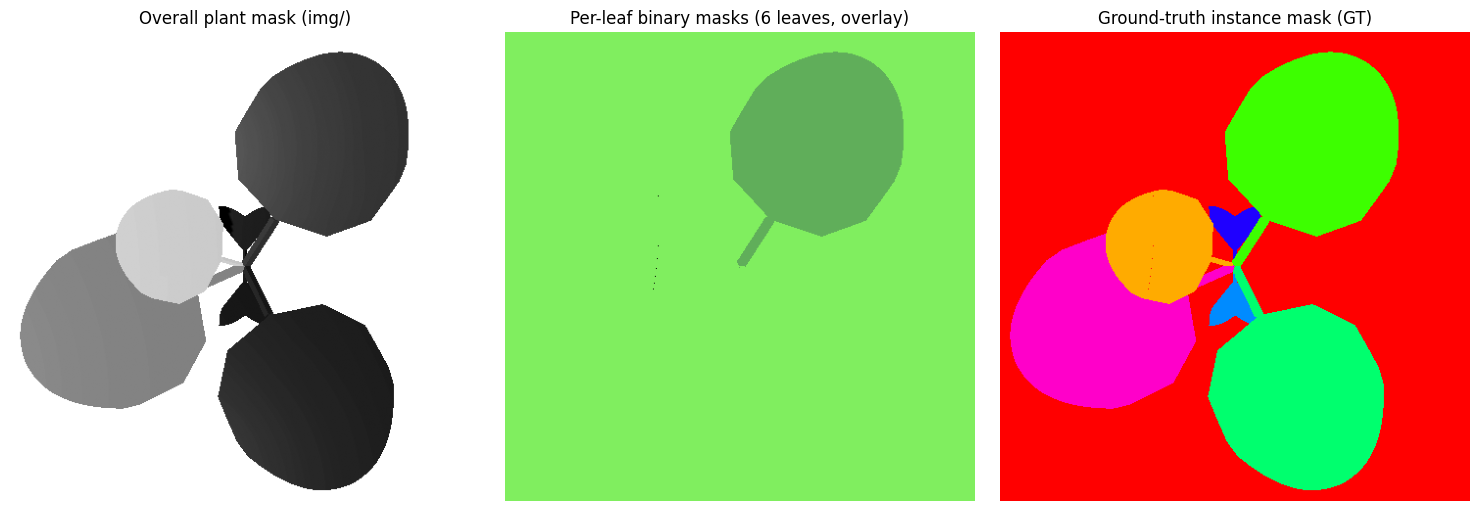

In [ ]:
# Preview generated masks and ground truth
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
items = [('Overall plant mask (img/)', overall[0]),
         (f'Per-leaf binary masks ({len(leaves)} leaves, overlay)', None),
         ('Ground-truth instance mask (GT)', gt_masks[0])]
axes[0].imshow(cv2.imread(items[0][1], cv2.IMREAD_GRAYSCALE), cmap='gray')
axes[0].set_title(items[0][0])
# overlay of all per-leaf binary masks, each leaf a random color
overlay = np.zeros((480, 480, 3), np.uint8)
rng = np.random.default_rng(meta['seed_value'])
for lp in leaves:
    m = cv2.imread(lp, cv2.IMREAD_GRAYSCALE)
    color = rng.integers(60, 255, 3)
    overlay[m % 2 == 1] = color
axes[1].imshow(overlay); axes[1].set_title(items[1][0])
gt = cv2.imread(items[2][1], cv2.IMREAD_GRAYSCALE)
axes[2].imshow(gt, cmap='hsv'); axes[2].set_title(items[2][0])
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Texturing with the pretrained komatsuna pix2pix generator
Uses the author `texturing.py` functions directly: each cropped leaf mask is padded to square, resized to
256×256, normalized, passed through the pretrained U-Net generator (`unet_256`, epoch 200), pasted back at its
bbox, and composited over a background image (`data_utility/src/background/CG_plant/komatsuna/`, one chosen
randomly by the author code).

**Adaptations (behavior-preserving):**
- `texturing.py`'s CLI hardcodes `torch.device(f'cuda:{gpu_id}')`; here we call the same functions with the
  detected device (CPU or CUDA). On CPU-only runtimes the author `networks.init_net` CUDA assert
  (`assert torch.cuda.is_available()`) is bypassed — the network init, `.to(device)`, and checkpoint load are identical.
- Komatsuna is **leaf-only**: `ckpt.zip` contains only `komatsuna/200_net_G_leaf.pth` (verified), and the
  authors' komatsuna processing creates no branch masks, so the branch-texturing branch of `texturing.main`
  is not invoked.
- **Generator depth correction**: the released komatsuna checkpoint contains exactly the parameter set of
  the author U-Net built with `num_downs=7` (70 tensors, verified key-by-key against `unet_128` in the
  author `networks.py`), while the author YAML says `netG: unet_256` (8 downs, 82 tensors), so the author
  configuration cannot load this checkpoint (strict key mismatch). We rebuild the generator with
  `netG='unet_128'` (num_downs=7) — the exact architecture of the released weights — verified by
  `load_state_dict(strict=True)` succeeding. All convolution/norm parameters, shapes and preprocessing
  are otherwise the author's.

Equival ent GUI action: *Texturing* tab (`app_function` → `texturing.py` CLI).

著者提供の学習済みpix2pix(komatsuna, epoch 200)で葉マスクをテクスチャリングします。CPUでも動作するようデバイス選択のみ適応させ、演算自体は著者コードのままです。

In [ ]:
# Load the author texturing module; select device; bypass the CUDA-only assert on CPU runtimes
os.chdir(f'{ROOT}/mask_generation/proc/texturing')   # author code uses relative config/ckpt paths
sys.path.insert(0, '.')
import texturing as T
from pix2pix import networks

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cpu':
    # Compatibility adaptation of networks.init_net: author code asserts CUDA availability
    # (pytorch-1.13-era GPU code). The operations below are otherwise identical.
    def init_net_cpu(net, device, init_type='normal', init_gain=0.02):
        net.to(device)
        networks.init_weights(net, init_type, init_gain=init_gain)
        return net
    networks.init_net = init_net_cpu

# The author YAML says netG: unet_256, but the released komatsuna checkpoint exactly matches the
# author U-Net built with num_downs=7 (netG 'unet_128'): 70 parameter tensors, key-for-key identical
# (verified). We therefore replicate T.load_pix2pix's three lines with netG corrected, and the
# author's strict load_state_dict loads the pretrained weights unchanged.
def load_pix2pix_komatsuna(device, species='komatsuna', text='leaf'):
    cfgs = T.load_yaml('./pix2pix/configs/pix2pix.yaml')
    cfgs['netG'] = 'unet_128'   # depth of the released checkpoint (see note above)
    G = T.create_model(cfgs, device)
    G.setup(cfgs, species, text)
    return G

t_load = time.time()
netG_leaf = load_pix2pix_komatsuna(device)
print(f'pix2pix komatsuna leaf generator loaded in {time.time()-t_load:.1f}s')

device: cpu
Load config from yaml file: ./pix2pix/configs/pix2pix.yaml


initialize network with normal


model [Pix2PixModel] was created
loading the model from ./pix2pix/ckpt/komatsuna/200_net_G_leaf.pth


pix2pix komatsuna leaf generator loaded in 1.1s


In [ ]:
# Texture each leaf mask and composite over a background (mirrors texturing.main for a leaf-only species)
import shutil

t_tex = time.time()
src_img = sorted(glob.glob(f'{CLD}/komatsuna/img/*.png'))[0]
source_img = cv2.imread(src_img)
processed_img = torch.tensor(source_img).to(device)

# author process_img for each cropped leaf mask (bbox .npy produced by proc_data)
for mask_path in leaf_masks:
    processed_img = T.process_img(mask_path, device, processed_img, netG_leaf, text='leaf', condition=False)

# foreground/background split from the white overall mask (same HSV threshold as author main())
hsv = cv2.cvtColor(source_img, cv2.COLOR_BGR2HSV)
fg = cv2.bitwise_not(cv2.inRange(hsv, (0, 0, 200), (180, 30, 255)))
bg_files = sorted(glob.glob(f'{ROOT}/data_utility/src/background/CG_plant/komatsuna/*.png'))
bg_id = np.random.default_rng(meta['seed_value']).integers(0, len(bg_files))
bg_img = cv2.imread(bg_files[bg_id])
textured = np.where(fg[..., None] == 0, bg_img, processed_img.cpu().numpy())
TEXTURED = '/content/leafgen/textured_komatsuna_000000.png'
cv2.imwrite(TEXTURED, textured)
print(f'texturing: {time.time()-t_tex:.1f}s | background file: {os.path.basename(bg_files[bg_id])} (id {bg_id} of {len(bg_files)})')
print('textured image:', TEXTURED, textured.shape)

texturing: 3.0s | background file: 000000.png (id 0 of 5)
textured image: /content/leafgen/textured_komatsuna_000000.png (480, 480, 3)


## 6. Result: synthetic textured plant + ground truth
Left: the synthetic leaf-textured image produced by the full pipeline. Right: its automatically generated
ground-truth instance mask. This is the type of (image, annotation) pair LeafGen produces **without any manual
annotation**; the paper then uses such generated datasets to train instance-segmentation models (out of scope here).

左:生成された合成画像。右:自動生成されたインスタンス分割の正解マスク。手作業のアノテーションなしに(画像, 正解)ペアが得られるのがLeafGenの要点です。

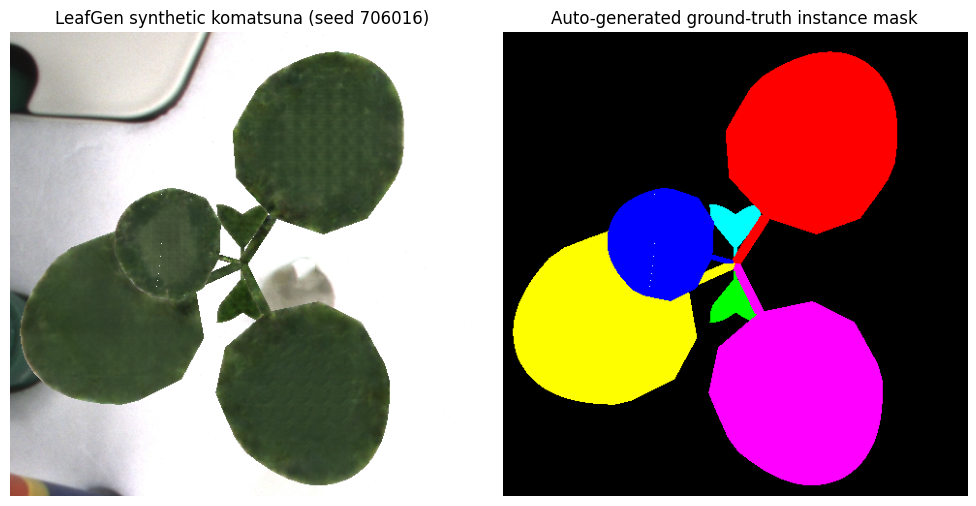

pipeline totals: generation 45.4s | processing 14.1s | texturing 3.6s


In [ ]:
# Show the final synthetic image next to its ground-truth instance mask
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(TEXTURED), cv2.COLOR_BGR2RGB))
axes[0].set_title('LeafGen synthetic komatsuna (seed %d)' % meta['seed_value'])
axes[1].imshow(cv2.cvtColor(cv2.imread(gt_masks[0]), cv2.COLOR_BGR2RGB))
axes[1].set_title('Auto-generated ground-truth instance mask')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'pipeline totals: generation {time.time()-t_gen:.1f}s | processing {time.time()-t_proc:.1f}s | texturing {time.time()-t_tex:.1f}s')

## Interpretation and limitations
- **Validated here**: one komatsuna plant (L-system → Blender masks → GT instance mask → pix2pix texturing), end to end, using only author-provided code, modified Blender build, and pretrained checkpoint (epoch 200). The leaf generator produces plausible leaf textures composed at each leaf's rendered position; occluded leaves remain fully occluded and are skipped in the GT (author logic).
- **What this is not**: a reproduction of the paper's dataset-scale experiments, its MaskDINO/Grounding-DINO segmentation results, or the pix2pix training procedure. A single generated plant does not establish the paper's reported segmentation accuracies.
- **Stochasticity**: the L-system uses Python `random` with unseeded sampling in the author script, so each run generates a different plant (the drawn seed is reported above and stored in the JSON/PLY filenames). Camera and background selection are reseeded from that seed in this notebook for reproducible compositing.
- **Environment note**: Blender 3.1 runs headless under `xvfb`; on Colab this is installed automatically in the setup cell.

**解釈と限界**: 著者提供コード・Blender・事前学習重みのみで1株の生成パイプラインを検証しました。L-systemの乱数は著者スクリプトのまま固定していないため、実行ごとに異なる株が生成されます。論文のデータセット規模の実験やMaskDINOの学習・評価は本ノートブックの対象外です。

## References
- Paper: *LeafGen: Structure-aware Leaf Image Generation for Annotation-free Leaf Instance Segmentation*, Plant Phenomics (2025), DOI 10.1016/j.plaphe.2025.100092.
- Author code: https://github.com/RightzZ/structure_gen @ `e32060d365ff7f1cea95b7985abdbd63c67592eb` (Apache-2.0); key files: `mask_generation/make_template_segdata.py`, `mask_generation/proc/texturing/texturing.py`, `mask_generation/proc/texturing/pix2pix/`, `data_utility/src/syn_plant/proc_data.py`, `app_function.py` (GUI→CLI parameter mapping).
- Author-provided artifacts (Google Drive folder linked in the repo README): modified `blender3.1.zip`, pretrained `ckpt.zip`.
- Background images: `data_utility/src/background/CG_plant/komatsuna/` from the same repository.
- L-system background: P. Prusinkiewicz & A. Lindenmayer, *The Algorithmic Beauty of Plants* (linked from the repo docs).